In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

import functools
from rich.progress import BarColumn, Progress, TextColumn, TimeRemainingColumn

from nerfstudio.engine.optimizers import Optimizers
from nerfstudio.engine.optimizers import AdamOptimizerConfig
from nerfstudio.engine.schedulers import ExponentialDecaySchedulerConfig
from nerfstudio.cameras.rays import RayBundle, RaySamples, Frustums
from reni.field_components.field_heads import RENIFieldHeadNames

from reni.configs.reni_config import RENIField
from reni.illumination_fields.environment_map_field import EnvironmentMapFieldConfig
from reni.illumination_fields.sh_illumination_field import SphericalHarmonicIlluminationFieldConfig
from reni.illumination_fields.sg_illumination_field import SphericalGaussianFieldConfig
from reni.utils.utils import find_nerfstudio_project_root
from reni.utils.colourspace import linear_to_sRGB

project_root = find_nerfstudio_project_root(Path(os.getcwd()))
os.chdir(project_root)

# setup config
test_mode = 'test'
world_size = 1
local_rank = 0
device = 'cuda:0'

reni_config = RENIField
reni_config.config.pipeline.datamanager.dataparser.custom_val_folder = Path('test/') # Set to custom data folder of .exr environment maps
reni_config.config.pipeline.datamanager.dataparser.eval_mask_path = Path('data/RENI_HDR/masks/01.png') # Set to desired mask folder
reni_config.config.pipeline.test_mode = test_mode
reni_config.config.pipeline.model_load_strict = False # As custom val folder is used, set to False
reni_config.config.vis = "tensorboard"

trainer = reni_config.config.setup(local_rank=local_rank, world_size=world_size)
trainer.setup(test_mode=test_mode)
pipeline = trainer.pipeline
datamanager = pipeline.datamanager

ray_bundle, batch = datamanager.next_eval(0)

[16:54:49] Saving checkpoints to: outputs/reni/reni/{timestamp}/nerfstudio_models                         ]8;id=991468;file:///home/james/github/ns_reni/nerfstudio/nerfstudio/engine/trainer.py\trainer.py]8;;\:]8;id=943511;file:///home/james/github/ns_reni/nerfstudio/nerfstudio/engine/trainer.py#142\142]8;;\

Setting up training dataset...

Caching all 3346 images.

Warning: If you run out of memory, try reducing the number of images to sample from.

Output()

...

Caching all 21 images.

Output()

Warning: Some cameras are equirectangular, but using default pixel sampler.

No Nerfstudio checkpoint to load, so training from scratch.

logging events to: outputs/reni/reni/{timestamp}

In [11]:
def create_ray_samples(origins, directions, camera_indices) -> RaySamples:
    """Create ray samples from a ray bundle"""

    ray_samples = RaySamples(
        frustums=Frustums(
            origins=origins,
            directions=directions,
            starts=torch.zeros_like(origins[:, 0]),
            ends=torch.ones_like(origins[:, 0]),
            pixel_area=torch.ones_like(origins[:, 0]),
        ),
        camera_indices=camera_indices,
    )

    return ray_samples

ray_samples = create_ray_samples(ray_bundle.origins, ray_bundle.directions, ray_bundle.camera_indices)
ray_samples = ray_samples.to('cpu')
ray_samples.camera_indices = torch.zeros_like(ray_samples.camera_indices)

In [7]:
envmap_field = EnvironmentMapFieldConfig(trainable=True).setup(num_train_data=1, num_eval_data=1, normalisations=None)
sh_field = SphericalHarmonicIlluminationFieldConfig().setup(num_train_data=1, num_eval_data=1, normalisations=None)
sg_field = SphericalGaussianFieldConfig(row_col_gaussian_dims=[5,1]).setup(num_train_data=1, num_eval_data=1, normalisations=None)

In [ ]:
envmap = envmap_field(ray_samples=ray_samples, rotation=None, latent_codes=None)
plt.imshow(envmap[RENIFieldHeadNames.RGB].reshape(64, 128, 3).numpy(force=True))

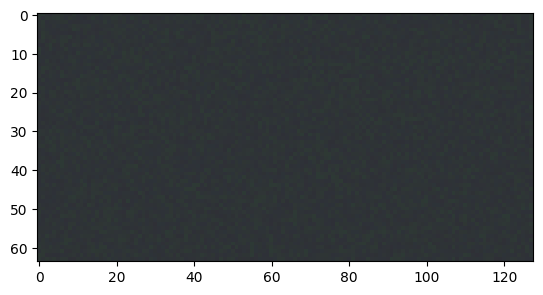

In [56]:
sh_params = torch.zeros(1, 9, 3)
# DC term (e.g., positive and around 0.5-1.0 for color)
sh_params[:, 0, :] = torch.rand(1, 3) * 0.5 + 0.5
# Higher-order terms (smaller variance)
sh_params[:, 1:, :] = torch.randn(1, 8, 3) * 0.01 # Or some other small scale_factor
sh_params = sh_params.repeat(128*64, 1, 1)
sh = sh_field(ray_samples=ray_samples, rotation=None, latent_codes=sh_params)
plt.imshow(sh[RENIFieldHeadNames.RGB].reshape(64, 128, 3).numpy(force=True))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.092907876..1.9762549].


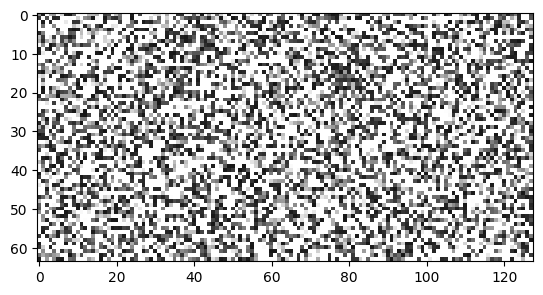

In [60]:
sg = sg_field(ray_samples=ray_samples, rotation=None, latent_codes=None)
plt.imshow(sg[RENIFieldHeadNames.RGB].reshape(64, 128, 3).numpy(force=True))